In [2]:
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scanpy as sc

/home/tester/miniforge3/envs/grn/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/tester/miniforge3/envs/grn/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/tester/miniforge3/envs/grn/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/tester/miniforge3/envs/grn/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/tester/miniforge3/envs/grn/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_

In [3]:
# adata_list = 
with open('/mnt/transfer/adata_list.pkl', 'rb') as f:
    adata_list = pickle.load(f)
print(adata_list)

[AnnData object with n_obs × n_vars = 10431 × 2000
    obs: 'Orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Percent.mt', 'Seurat_clusters', 'Celltype', 'Dataset', 'Tissue', 'Organ', 'Condition', 'Genotype', 'Libraries', 'ACE', 'Orig_ident'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'neighbors', 'umap', 'Celltype_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities', AnnData object with n_obs × n_vars = 10431 × 2000
    obs: 'Orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Percent.mt', 'Seurat_clusters', 'Celltype', 'Dataset', 'Tissue', 'Organ', 'Condition', 'Genotype', 'Libraries', 'ACE', 'Orig_ident'
    var: 'features', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'umap', 'Celltype_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities', AnnData object with n_obs × n_vars = 10431 × 2000
    obs: 'Orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Percent.mt', 'Seur

In [4]:
adata_names = ["Original data", "DeepTAN", "scGPT", "Monae", "MIDAS", "scButterfly"]

In [ ]:
# 获取所有文件中唯一的细胞类型标签
all_cell_types = set()
for _adata in adata_list:
    all_cell_types.update(_adata.obs['Celltype'].unique())  # 假设细胞类型列名为 'cell_type'
all_cell_types = sorted(all_cell_types)
print(all_cell_types)
# 获取所有文件中唯一的样本来源标签
all_Orig_ident = set()
for _adata in adata_list:
    all_Orig_ident.update(_adata.obs['Orig_ident'].unique())  # 假设细胞类型列名为 'cell_type'
all_Orig_ident = sorted(all_Orig_ident)
print(all_Orig_ident)

['Columella root cap', 'Companion cell', 'G1/G0 phase', 'G2/M phase', 'Lateral root cap', 'Non-hair', 'Pericycle', 'Phloem', 'Root cortex', 'Root endodermis', 'Root hair', 'Root procambium', 'S phase', 'Stem cell niche', 'Xylem']
['SRX8840337', 'SRX8840338', 'SRX8840339', 'SRX8840340', 'SRX8840341']


In [22]:
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

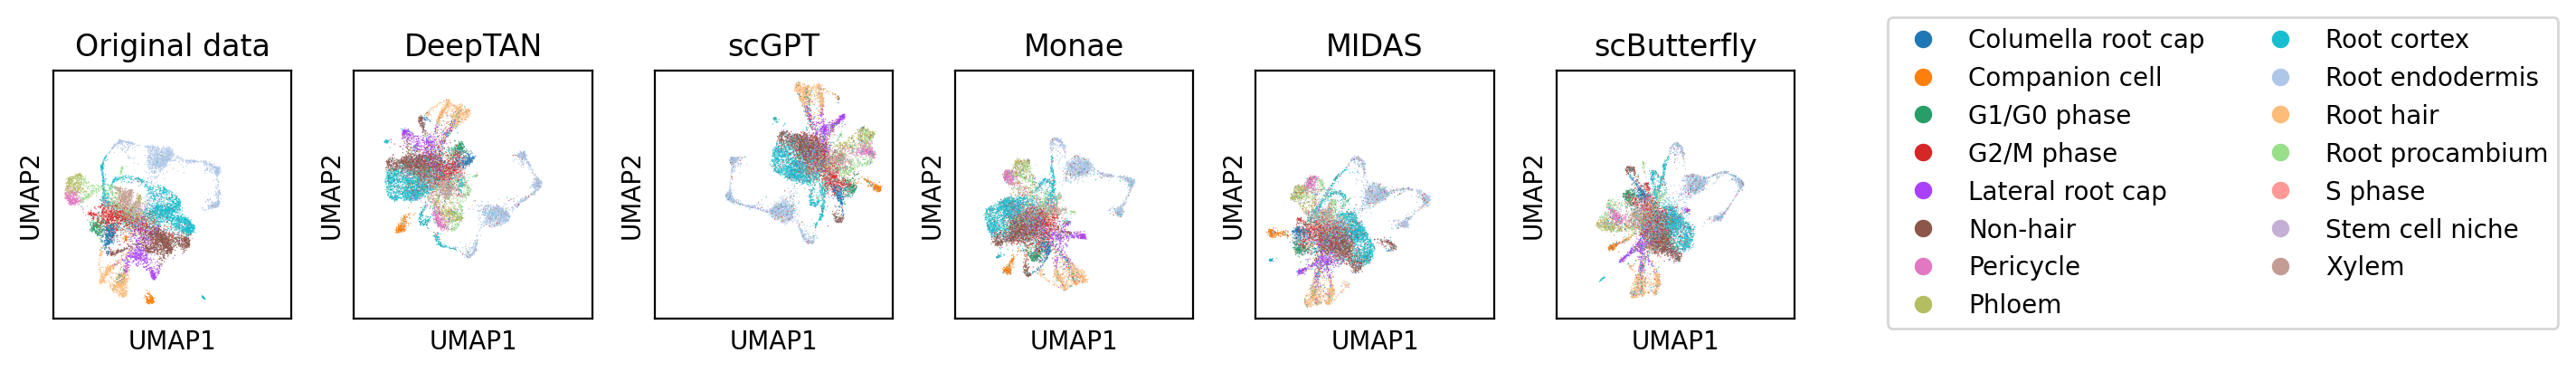

In [44]:
n_adata = len(adata_list)

# A4纸的宽度约为21厘米（8.27英寸），高度可以根据需要调整
a4_width_cm = 21
cm_to_inches = 0.393701
a4_width_inches = a4_width_cm * cm_to_inches

n_cols = 7  # 每行最多显示 7 个子图
n_rows = (n_adata + n_cols - 1) // n_cols

fig_height = 2.3 * n_rows  # 每行高度为 

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(a4_width_inches * 1.5, fig_height),
    sharex=True,
    sharey=True,
)
if n_rows == 1:
    axes = axes.reshape(1, -1)

# 绘制每个文件的 UMAP 图(Celltype)
for i, _adata in enumerate(adata_list):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    sc.pl.umap(
        _adata,
        color="Celltype",
        size=1,
        alpha=0.8,
        title=adata_names[i],
        show=False,
        ax=ax,
        legend_loc=None,
    )

#绘制共享图例
legend_labels = all_cell_types
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=cell_type,
        markerfacecolor=color,
        markersize=8,
    )
    for cell_type, color in zip(
        all_cell_types, sc.pl.palettes.default_20[: len(all_cell_types)]
    )
]
fig.legend(legend_elements, legend_labels, loc='right', bbox_to_anchor=(1.15, 0.5), ncol=2)
# 如果子图数量不足，隐藏多余的子图
for i in range(n_adata, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].axis('off')

# 调整布局以避免重叠
plt.tight_layout(rect=(0, 0, 0.95, 0.9))  # 为图例留出空间


# 调整布局以避免重叠
#plt.tight_layout()

# 显示图像
plt.show()

In [ ]:
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

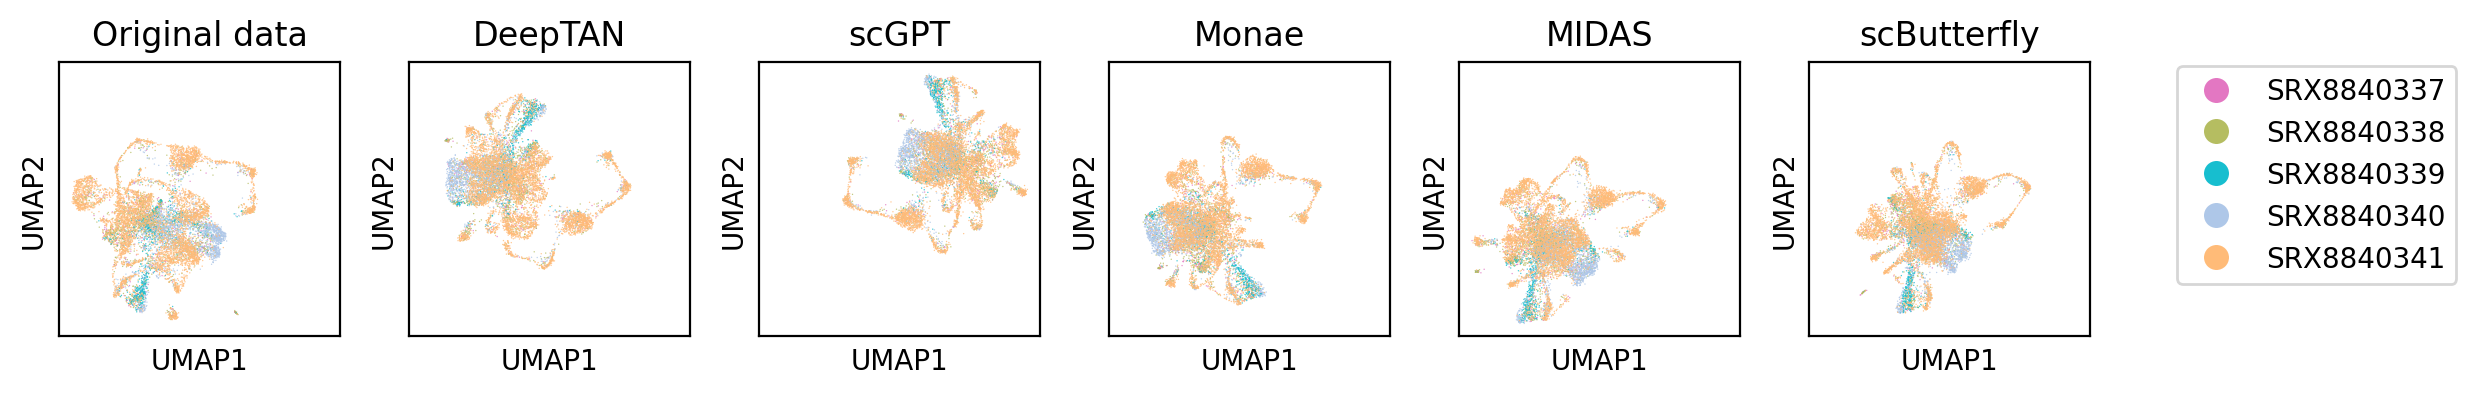

In [54]:
n_adata = len(adata_list)

# A4纸的宽度约为21厘米（8.27英寸），高度可以根据需要调整
a4_width_cm = 21
cm_to_inches = 0.393701
a4_width_inches = a4_width_cm * cm_to_inches

n_cols = 7  # 每行最多显示 7 个子图
n_rows = (n_adata + n_cols - 1) // n_cols

fig_height = 2.3 * n_rows  # 每行高度为 

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(a4_width_inches * 1.5, fig_height),
    sharex=True,
    sharey=True,
)
if n_rows == 1:
    axes = axes.reshape(1, -1)

# 绘制每个文件的 UMAP 图(Celltype)
reversed_palette = sc.pl.palettes.default_20[6:11]
for i, _adata in enumerate(adata_list):
    row, col = i // n_cols, i % n_cols
    ax = axes[row, col]
    sc.pl.umap(
        _adata,
        color="Orig_ident",
        palette=reversed_palette[:len(all_Orig_ident)],
        size=1,
        alpha=0.8,
        title=adata_names[i],
        show=False,
        ax=ax,
        legend_loc=None,
    )

#绘制共享图例
reversed_palette = sc.pl.palettes.default_20[6:11]
legend_labels = all_Orig_ident
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=all_Orig_ident,
        markerfacecolor=color,
        markersize=10,
    )
    # for Orig_ident, color in zip(
    #     all_Orig_ident, sc.pl.palettes.default_20[: len(all_Orig_ident)]
    # )
    for Orig_ident, color in zip(
        all_Orig_ident, reversed_palette[: len(all_Orig_ident)]
    )
]
fig.legend(legend_elements, legend_labels, loc='right', bbox_to_anchor=(1, 0.5), ncol=1)
# 如果子图数量不足，隐藏多余的子图
for i in range(n_adata, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row, col].axis('off')

# 调整布局以避免重叠
plt.tight_layout(rect=(0, 0, 1, 0.9))  # 为图例留出空间


# 调整布局以避免重叠
#plt.tight_layout()

# 显示图像
plt.show()